In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/credit_risk_dataset.csv')
df = df.dropna()
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['loan_status'].value_counts())
df.head()

Dataset shape: (28632, 12)

Target distribution:
loan_status
0    22430
1     6202
Name: count, dtype: int64


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


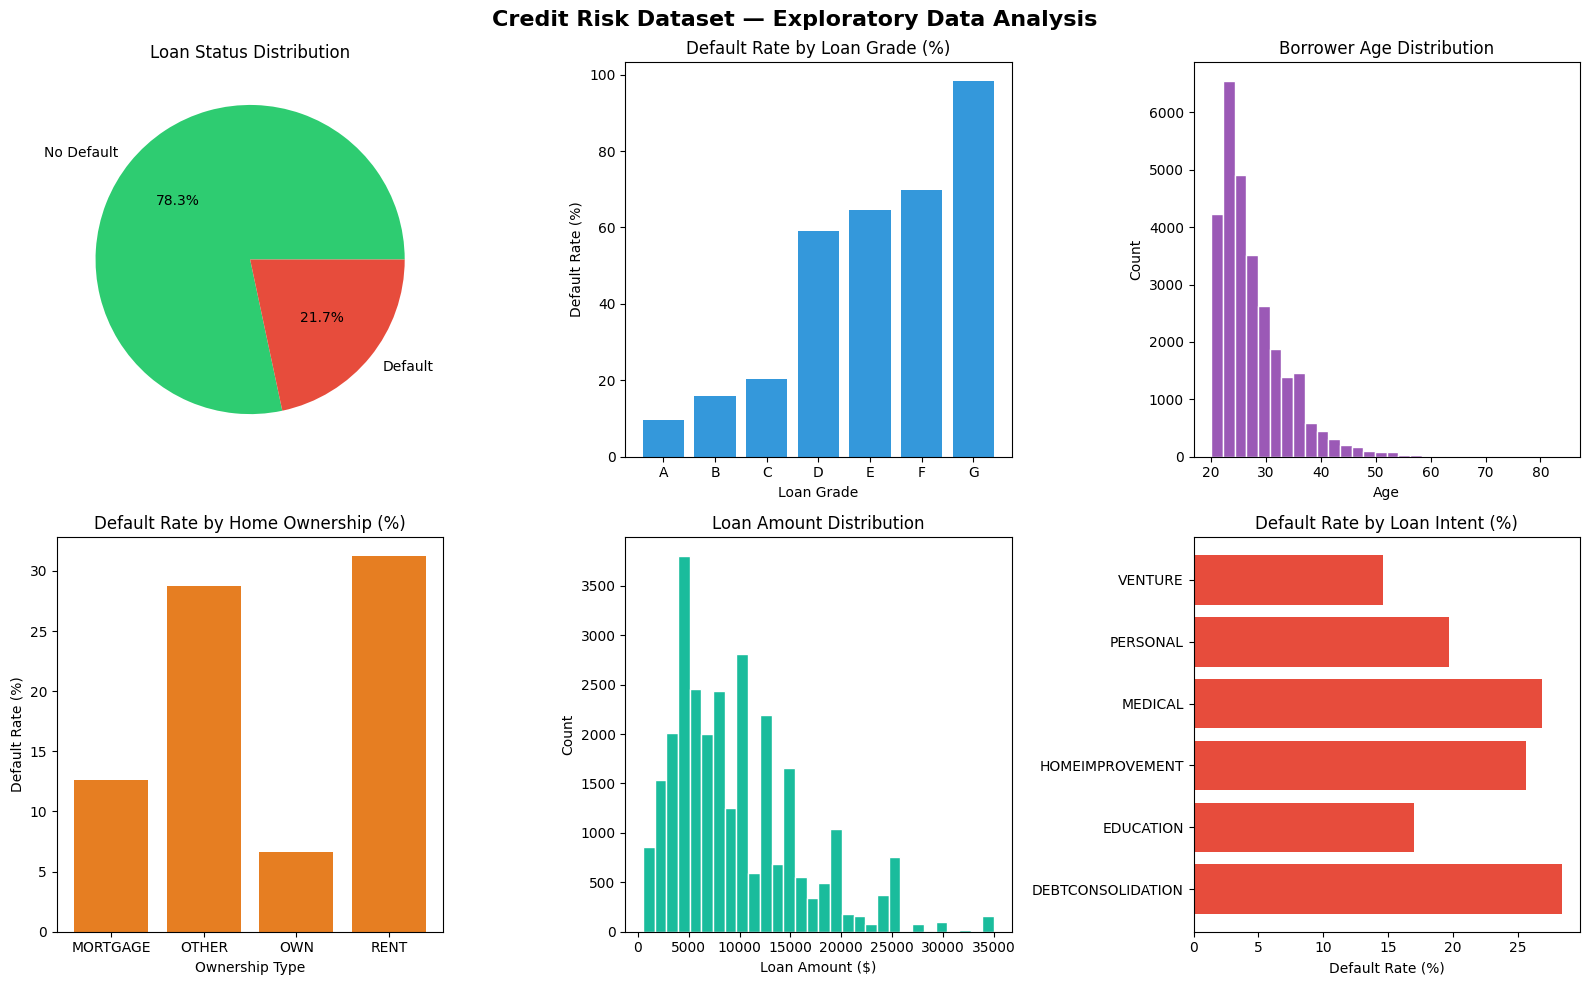

✅ Charts saved!


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Credit Risk Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Target distribution
axes[0,0].pie(df['loan_status'].value_counts(), labels=['No Default', 'Default'], 
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Loan Status Distribution')

# 2. Default rate by loan grade
grade_default = df.groupby('loan_grade')['loan_status'].mean() * 100
axes[0,1].bar(grade_default.index, grade_default.values, color='#3498db')
axes[0,1].set_title('Default Rate by Loan Grade (%)')
axes[0,1].set_xlabel('Loan Grade')
axes[0,1].set_ylabel('Default Rate (%)')

# 3. Age distribution
axes[0,2].hist(df['person_age'], bins=30, color='#9b59b6', edgecolor='white')
axes[0,2].set_title('Borrower Age Distribution')
axes[0,2].set_xlabel('Age')
axes[0,2].set_ylabel('Count')

# 4. Default rate by home ownership
own_default = df.groupby('person_home_ownership')['loan_status'].mean() * 100
axes[1,0].bar(own_default.index, own_default.values, color='#e67e22')
axes[1,0].set_title('Default Rate by Home Ownership (%)')
axes[1,0].set_xlabel('Ownership Type')
axes[1,0].set_ylabel('Default Rate (%)')

# 5. Loan amount distribution
axes[1,1].hist(df['loan_amnt'], bins=30, color='#1abc9c', edgecolor='white')
axes[1,1].set_title('Loan Amount Distribution')
axes[1,1].set_xlabel('Loan Amount ($)')
axes[1,1].set_ylabel('Count')

# 6. Default rate by loan intent
intent_default = df.groupby('loan_intent')['loan_status'].mean() * 100
axes[1,2].barh(intent_default.index, intent_default.values, color='#e74c3c')
axes[1,2].set_title('Default Rate by Loan Intent (%)')
axes[1,2].set_xlabel('Default Rate (%)')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")


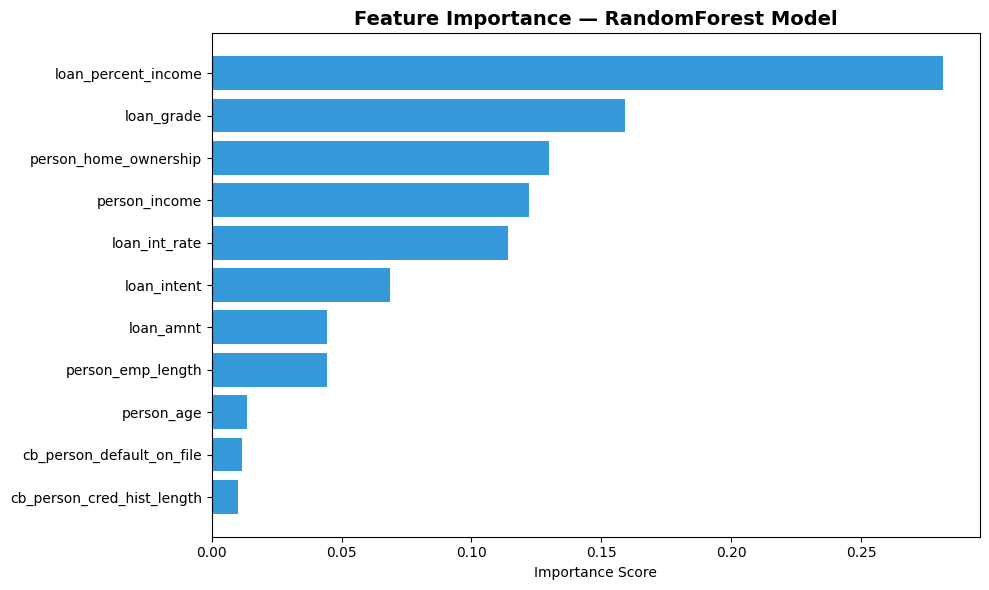

✅ Feature importance saved!


In [4]:
# Feature importance from the trained model
import joblib
import numpy as np

model = joblib.load('../ml/model.pkl')
features = ['person_age', 'person_income', 'person_home_ownership', 
            'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
            'cb_person_cred_hist_length']

importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh([features[i] for i in indices], importances[indices], color='#3498db')
plt.title('Feature Importance — RandomForest Model', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved!")